<a href="https://colab.research.google.com/github/alzimnara/modul_praktikum/blob/main/notebooks/notebook_praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install damagescanner
!pip install contextily
!pip install osmnx

import warnings
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import shapely

import matplotlib.pyplot as plt
import contextily as cx
import osmnx as ox

import logging
import urllib.request
from pathlib import Path
from urllib.parse import urljoin

import zipfile
import os
import glob

import damagescanner.download as download
from damagescanner.core import DamageScanner
from damagescanner.osm import read_osm_data
from damagescanner.config import DICT_CIS_VULNERABILITY_FLOOD

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning) # exactextract gives a warning that is invalid

# Download Hazard Map dari CDRI

In [ ]:
hazard_map = xr.open_dataset("https://hazards-data.unepgrid.ch/global_pc_h100glob.tif", engine="rasterio")

In [ ]:
hazard_map

<xarray.Dataset> Size: 747GB
Dimensions:      (band: 1, x: 432000, y: 216000)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 3MB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * y            (y) float64 2MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0 -90.0
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float64 746GB ...

# Download batas kota

In [ ]:
city_name = "Demak, Jawa Tengah, Jawa, Indonesia"

In [ ]:
city_gdf = ox.geocode_to_gdf(city_name)
city_crs = city_gdf.crs  # usually EPSG:4326
city_geom = city_gdf.geometry.iloc[0]
print("City CRS:", city_crs)
city_gdf

City CRS: epsg:4326


,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((110.46359 -6.92819, 110.4655 -6.9319...",110.463587,-7.139686,110.838949,-6.70612,407304861,relation,17241173,-6.923095,110.627667,boundary,administrative,12,0.463288,county,Demak,"Demak, Central Java, Java, Indonesia"


<Axes: >

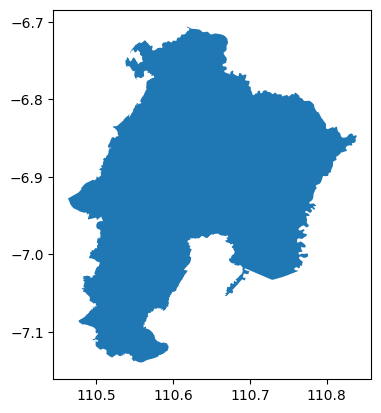

In [ ]:
city_gdf.plot()

# Download data building dengan osmnx

In [ ]:
tags = {"building" : True}
gdf_osm = ox.features.features_from_polygon(city_geom, tags)

In [ ]:
gdf_osm

geometry  \
element id                                                               
node    2678539326                          POINT (110.67276 -6.83629)   
        3121811213                          POINT (110.58259 -6.87999)   
        5298918482                          POINT (110.63713 -6.89433)   
        6144454668                          POINT (110.51355 -7.03613)   
        12223605500                          POINT (110.6543 -6.88448)   
...                                                                ...   
way     1459108394   POLYGON ((110.63133 -6.96674, 110.63131 -6.966...   
        1459108395   POLYGON ((110.63129 -6.96579, 110.63131 -6.965...   
        1473275472   POLYGON ((110.52659 -7.0274, 110.52671 -7.0274...   
        1477818826   POLYGON ((110.5844 -7.03628, 110.58443 -7.0362...   
        1477818827   POLYGON ((110.58463 -7.03634, 110.58468 -7.036...   

                    building                                  name  \
element id                                                           
node    2678539326     house                         Hadi Prayitno   
        3121811213    school                TK Mardisiwi Kembangan   
        5298918482       yes          Makam Rd. Sultan Fatah Demak   
        6144454668    mosque                                   NaN   
        12223605500      yes        Kantor Maxim Indonesia - Demak   
...                      ...                                   ...   
way     1459108394       yes                                   NaN   
        1459108395       yes                                   NaN   
        1473275472       yes  SPBU Pertamina 44.595.05 Kembangarum   
        1477818826       yes                                   NaN   
        1477818827       yes                                   NaN   

                    access:roof                             addr:full  \
element id                                                              
node    2678539326          NaN                                   NaN   
        3121811213          yes  Desa Ngasinan Kembangan Bonang Demak   
        5298918482          NaN                                   NaN   
        6144454668          yes                                   NaN   
        12223605500         NaN                                   NaN   
...                         ...                                   ...   
way     1459108394          NaN                                   NaN   
        1459108395          NaN                                   NaN   
        1473275472          NaN                                   NaN   
        1477818826          NaN                                   NaN   
        1477818827          NaN                                   NaN   

                              amenity building:levels building:roof  \
element id                                                            
node    2678539326                NaN             NaN           NaN   
        3121811213             school               3          tile   
        5298918482                NaN             NaN           NaN   
        6144454668   place_of_worship               2      concrete   
        12223605500               NaN             NaN           NaN   
...                               ...             ...           ...   
way     1459108394                NaN             NaN           NaN   
        1459108395                NaN             NaN           NaN   
        1473275472               fuel             NaN           NaN   
        1477818826                NaN             NaN           NaN   
        1477818827                NaN             NaN           NaN   

                     building:structure building:walls  ... house landuse  \
element id                                              ...                 
node    2678539326                  NaN            NaN  ...   NaN     NaN   
        3121811213   reinforced_masonry          brick  ...   NaN     NaN   
      

In [ ]:
gdf_osm_poly = gdf_osm[gdf_osm.geom_type.isin(["Polygon"])].copy()

In [ ]:
gdf_osm_poly = gdf_osm_poly.explode(index_parts=False).reset_index(drop=False)

In [ ]:
features = gdf_osm_poly[["id", "building", "geometry"]].copy()
features = gpd.GeoDataFrame(features, geometry="geometry", crs=city_crs)
features = features[features["geometry"].notna()].copy()

print("Raw buildings rows:", len(features))
features.head()

Raw buildings rows: 240653


,id,building,geometry
0,9618308,yes,"POLYGON ((110.63533 -6.91809, 110.63535 -6.918..."
1,17421937,yes,"POLYGON ((110.69323 -6.94863, 110.69333 -6.948..."
2,17478642,yes,"POLYGON ((110.75934 -6.81915, 110.75933 -6.819..."
3,17542253,yes,"POLYGON ((110.55456 -7.1134, 110.55459 -7.1133..."
4,17542254,yes,"POLYGON ((110.55456 -7.1134, 110.55461 -7.1134..."


# Download data bangunan dengan geofabrik

In [ ]:
# download_url = f"https://download.geofabrik.de/asia/indonesia/java-latest-free.shp.zip"
# filepath = Path("/content/", Path(download_url).name)
# filepath.parent.mkdir(exist_ok=True, parents=True)
# try :
#   urllib.request.urlretrieve(download_url, filepath)
# except Exception as e:
#     warnings.warn(f"Download Error: {e}", UserWarning)

# zip_file_path = '/content/java-latest-free.shp.zip'
# destination_dir = '/content/java-latest-free.shp'

# os.makedirs(destination_dir, exist_ok=True)

# with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#     zip_ref.extractall(destination_dir)

# file_pattern = "/content/java-latest-free.shp/gis_osm_buildings_a_free_*.shp"
# shapefiles = glob.glob(file_pattern)

# gdfs = []
# for file in shapefiles:
#     gdf = gpd.read_file(
#         file,
#         mask=city_geom,
#         engine="pyogrio",
#         on_invalid="ignore"
#     )
#     gdfs.append(gdf)

# features2 = pd.concat(gdfs, ignore_index=True)

Extracted to: /content/java-latest-free.shp


In [ ]:
url = "https://github.com/alzimnara/modul_praktikum/raw/refs/heads/main/data/processed/Building%20Geofrabrik/building_demak_geofabrik.shp"
building_geofabrik = gpd.read_file(url)

<Axes: >

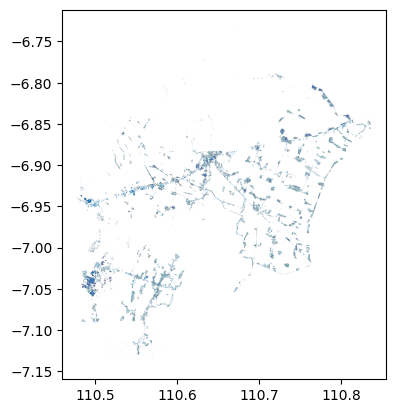

In [ ]:
building_geofabrik.plot()